In [1]:
from ultralytics import YOLO
model = YOLO("ball_detection.pt")

results = model.predict(
    source="../source/stug_test.mp4",
    save=True,
    device=0,
    conf=0.25,
    max_det=1
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detections), 227.3ms
video 1/1 (frame 2/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detections), 114.1ms
video 1/1 (frame 3/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detec

In [5]:
from ultralytics import YOLO
model = YOLO("ball_detection.pt")

results = model.predict(
    source="../source/stug_test.mp4",
    save=True,
    device=0,
    conf=0.25,
    max_det=1
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detections), 55.1ms
video 1/1 (frame 2/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detections), 51.2ms
video 1/1 (frame 3/540) c:\Users\ferdi\Studium\6. Semester DSC\Domnenprojekt I\ball-detectionv2\yolo\..\source\stug_test.mp4: 288x512 (no detecti

NameError: name 'equal' is not defined

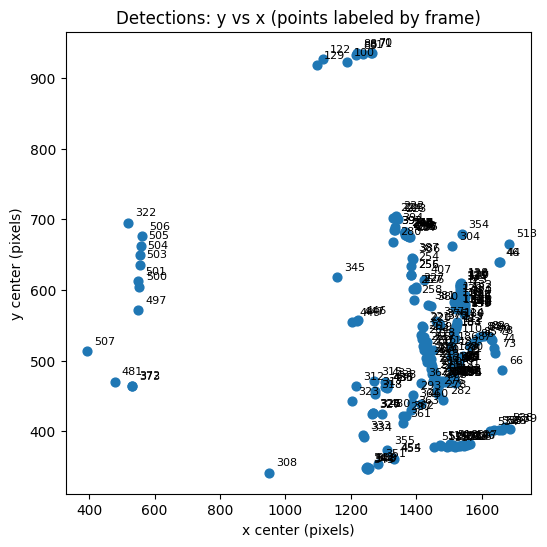

In [8]:
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you already have results from your predict call, skip re-running predict.
# Otherwise uncomment and run the two lines below to produce `results`.
# model = YOLO("ball_detection.pt")
# results = model.predict(source="../source/stug_test.mp4", save=True, device=0, conf=0.25, max_det=1)

data = []
for frame_idx, r in enumerate(results):
    # r.boxes may be empty if no detection on that frame
    if getattr(r, "boxes", None) is None:
        continue
    try:
        xyxy = r.boxes.xyxy.cpu().numpy() if len(r.boxes) > 0 else np.empty((0,4))
    except Exception:
        try:
            xyxy = r.boxes.cpu().numpy()
        except Exception:
            xyxy = np.empty((0,4))
    for box in xyxy:
        x1, y1, x2, y2 = box[:4]
        xc = (x1 + x2) / 2.0
        yc = (y1 + y2) / 2.0
        data.append({"frame": frame_idx, "x": float(xc), "y": float(yc)})

df = pd.DataFrame(data)
if df.empty:
    print("No detections found.")
else:
    # Scatter plot: x vs y, and label each point with its frame number
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(df["x"], df["y"], c="C0", s=40)
    for _, row in df.iterrows():
        ax.annotate(str(int(row['frame'])), (row['x'], row['y']), textcoords="offset points", xytext=(5,5), fontsize=8)
    ax.set_xlabel("x center (pixels)")
    ax.set_ylabel("y center (pixels)")
    ax.set_title("Detections: y vs x (points labeled by frame)")
    plt.gca().set_aspect(equal, adjustable=box)
    plt.tight_layout()
    plt.show()
    fig.savefig("y_vs_x_labeled.png", dpi=200)
